#Indications :

On déjà devant ton second checkpoint.

Les 3 parties principaux sont indépendants. Tu peux donc les effectuer dans l'ordre que tu préfères. Ils se basent tous sur le même dataset.

Essaye de finir ce checkpoint en 4h. Si tu n'as pas tout fini, ce n'est pas grave. Tu pourras le reprendre plus tard, tu indiqueras simplement en commentaire ce que tu as fait a posteriori.
Nous t'avons indiqué des durées estimatives.

Évidemment chacun a ses forces et ses faiblesses, avance donc à ton rythme. **Cependant, si tu vois que tu dépasses une durée, ne reste pas bloqué, passe à l'exercice suivant.** Tu pourras revenir à la fin sur ce que tu n'as pas fini.

Il y a deux questions bonus à la fin. Ce sont des exercices pour aller plus loin. Ils sont assez stimulants pour de l'analyse.

**P.S : Lis très bien les consignes, les exercices sont guidés, si tu sens que tu es allé très loin dans l'exercice, relis ta consigne, tu as surement raté un détail.**


# **Checkpoint 2**
Exécute le code ci-dessous.

In [1]:
# DataFrame et array
import pandas as pd
import numpy as np
# Graphiques - Visulaisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# Machine-learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression

url = "https://raw.githubusercontent.com/murpi/wilddata/master/quests/spotify.zip"
df_music = pd.read_csv(url)
df_music.loc[(df_music["energy"] > 0.2) & (df_music["energy"] < 0.22) & (df_music["genre"].isin(["Opera" , "Reggaeton"]) == False), "liveness" ] = np.nan
df_music

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.61100,0.389,99373,0.910,0.000000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.24600,0.590,137373,0.737,0.000000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.95200,0.663,170267,0.131,0.000000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.70300,0.240,152427,0.326,0.000000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.95000,0.331,82625,0.225,0.123000,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232720,Soul,Slave,Son Of Slide,2XGLdVl7lGeq8ksM6Al7jT,39,0.00384,0.687,326240,0.714,0.544000,D,0.0845,-10.626,Major,0.0316,115.542,4/4,0.962
232721,Soul,Jr Thomas & The Volcanos,Burning Fire,1qWZdkBl4UVPj9lK6HuuFM,38,0.03290,0.785,282447,0.683,0.000880,E,0.2370,-6.944,Minor,0.0337,113.830,4/4,0.969
232722,Soul,Muddy Waters,(I'm Your) Hoochie Coochie Man,2ziWXUmQLrXTiYjCg2fZ2t,47,0.90100,0.517,166960,0.419,0.000000,D,0.0945,-8.282,Major,0.1480,84.135,4/4,0.813
232723,Soul,R.LUM.R,With My Words,6EFsue2YbIG4Qkq8Zr9Rir,44,0.26200,0.745,222442,0.704,0.000000,A,0.3330,-7.137,Major,0.1460,100.031,4/4,0.489


# **Analyse Exploratoire des Données et Traitement des Données (environ 1h30)**

## 1.1 Introduction
Affichez les 6 premières lignes du jeu de données.

In [2]:
# Your code here :
df_music.head(6)

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.9100,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.7370,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.1310,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.3260,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.2250,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390
5,Movie,Henri Salvador,Le petit souper aux chandelles,0Mf1jKa8eNAf1a4PwTbizj,0,0.749,0.578,160627,0.0948,0.000,C#,0.1070,-14.970,Major,0.1430,87.479,4/4,0.358


Décrivez le jeu de données et commentez la colonne popularity.

In [3]:
# Your code here :
df_music.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
popularity,232725.0,41.127502,18.189948,0.00000,29.0000,43.000000,55.0000,100.000
acousticness,232725.0,0.368560,0.354768,0.00000,0.0376,0.232000,0.7220,0.996
danceability,232725.0,0.554364,0.185608,0.05690,0.4350,0.571000,0.6920,0.989
duration_ms,232725.0,235122.339306,118935.909299,15387.00000,182857.0000,220427.000000,265768.0000,5552917.000
energy,232725.0,0.570958,0.263456,0.00002,0.3850,0.605000,0.7870,0.999
instrumentalness,232725.0,0.148301,0.302768,0.00000,0.0000,0.000044,0.0358,0.999
liveness,230620.0,0.215437,0.198630,0.00967,0.0974,0.129000,0.2650,1.000
loudness,232725.0,-9.569885,5.998204,-52.45700,-11.7710,-7.762000,-5.5010,3.744
speechiness,232725.0,0.120765,0.185518,0.02220,0.0367,0.050100,0.1050,0.967
tempo,232725.0,117.666585,30.898907,30.37900,92.9590,115.778000,139.0540,242.903


In [4]:
df_music.describe(exclude='number').T

,count,unique,top,freq
genre,232725,27,Comedy,9681
artist_name,232725,14564,Giuseppe Verdi,1394
track_name,232724,148614,Home,100
track_id,232725,176774,0wY9rA9fJkuESyYm9uzVK5,8
key,232725,12,C,27583
mode,232725,2,Major,151744
time_signature,232725,5,4/4,200760


Vérifiez la présence / absence de valeurs manquantes dans chaque colonne et commentez votre résultat.

In [5]:
# Your code here :
missing = df_music.isna().sum().sort_values(ascending=False)
print("Nombre de valeurs manquantes par colonne :")
print(missing[missing > 0])

# Seule les colonnes `liveness` et `track_name` contiennent des valeurs manquantes
# La configuration du dataset au démaragge introduit les valeurs manquantes dans `liveness`
# Toutes les autres colonnes sont complètes.

Nombre de valeurs manquantes par colonne :
liveness      2105
track_name       1
dtype: int64


## 1.2 Des informations sur les artistes
Donnez le nombre de morceaux pour chaque artiste.

Voici les premières lignes attendues :


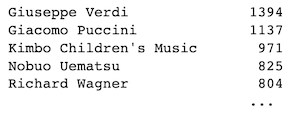

In [6]:
# Your code here :
# Affichage du nombre de morceaux par artistes
nb_morceaux = df_music['artist_name'].value_counts()
nb_morceaux.head(10)

artist_name
Giuseppe Verdi             1394
Giacomo Puccini            1137
Kimbo Children's Music      971
Nobuo Uematsu               825
Richard Wagner              804
Wolfgang Amadeus Mozart     800
Randy Newman                757
Georges Bizet               701
Juice Music                 684
Johann Sebastian Bach       632
Name: count, dtype: int64


Donnez la moyenne de popularité pour chaque artiste. Le résultat sera trié par ordre décroissant pour une meilleure lisibilité.

*Vous pouvez utiliser `groupby`, `crosstab` ou `pivot_table` pour répondre à ces questions.*

Voici les premières lignes attendues :

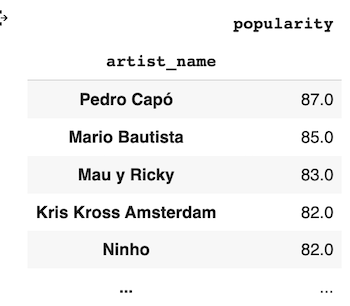

In [7]:
# Your code here :
# Affichage décroissant des valeurs correspondant à la serie `popularity`
popularite_moyenne = df_music.groupby('artist_name')['popularity'].mean().sort_values(ascending=False).round(1)
popularite_moyenne.head(10)

artist_name
Pedro Capó              87.0
Mario Bautista          85.0
Mau y Ricky             83.0
Paloma Mami             82.0
Ninho                   82.0
Kris Kross Amsterdam    82.0
Martin Garrix           81.9
Sofia Reyes             81.5
NSG                     81.0
Anitta                  81.0
Name: popularity, dtype: float64

## 1.3 Qu'en est-il de Queen ?
Affichez un DataFrame contenant uniquement Queen.
Vous devriez obtenir 97 lignes.

In [8]:
# Your code here :
# Filtre puis affichage d'un dataset contenant uniquement le groupe Queen
df_queen = df_music[df_music['artist_name'] == 'Queen']
print(f"Nombre de lignes : {len(df_queen)}")
df_queen.head()

Nombre de lignes : 97


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
152988,Rock,Queen,We Are The Champions,4kzvAGJirpZ9ethvKZdJtg,50,0.23000,0.460,180667,0.482,0.000000,A#,0.101,-7.413,Major,0.0285,94.975,3/4,0.202
153284,Rock,Queen,"Get Down, Make Love - Remastered 2011",1DdC1R2eDWg3Xq9RPSX4h2,50,0.42300,0.441,230120,0.723,0.000000,G#,0.360,-4.746,Major,0.2570,143.711,4/4,0.454
153622,Rock,Queen,Sheer Heart Attack - Remastered 2011,5AHQ3hXjXQzmtCT5iEkh2f,50,0.00867,0.359,207600,0.931,0.001890,A#,0.359,-4.564,Major,0.1080,91.499,4/4,0.418
153734,Rock,Queen,Seaside Rendezvous - Remastered 2011,5w49nWH532c39tuJ3kthEm,49,0.40800,0.450,134133,0.706,0.000000,C,0.292,-5.462,Major,0.1130,167.906,4/4,0.764
154806,Rock,Queen,Sleeping On The Sidewalk - Remastered 2011,6T4mvqvMIwa0S6EH84QAAJ,48,0.48400,0.615,186080,0.770,0.000168,E,0.325,-7.674,Major,0.0274,129.734,4/4,0.645


Quelles sont leurs 3 chansons les plus populaires ?

Voici les lignes attendues :

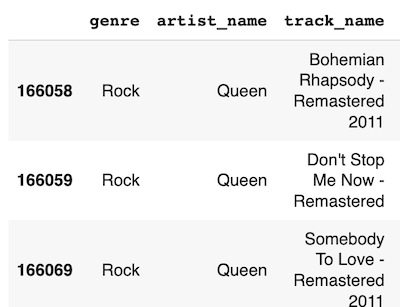

In [9]:
# Your code here :
# Top 3 des chansons les plus populaires du groupe Queen
top3_queen = df_queen.sort_values('popularity', ascending=False).head(3)
top3_queen[['genre', 'artist_name', 'track_name', 'popularity']]

,genre,artist_name,track_name,popularity
166058,Rock,Queen,Bohemian Rhapsody - Remastered 2011,82
166059,Rock,Queen,Don't Stop Me Now - Remastered,81
166067,Rock,Queen,Under Pressure - Remastered,77


## 1.4 Transformation
En utilisant `apply`, créez une nouvelle colonne `most_popular` qui contient :
- "Most popular" si la popularité est supérieure ou égale à 90
- "Other song" sinon.

In [10]:
# Your code here :
df_music['most_popular'] = df_music['popularity'].apply(lambda x : "Most popular" if x >= 90 else "Other song")
df_music[['artist_name', 'track_name', 'popularity', 'most_popular']].head()

,artist_name,track_name,popularity,most_popular
0,Henri Salvador,C'est beau de faire un Show,0,Other song
1,Martin & les fées,Perdu d'avance (par Gad Elmaleh),1,Other song
2,Joseph Williams,Don't Let Me Be Lonely Tonight,3,Other song
3,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0,Other song
4,Fabien Nataf,Ouverture,4,Other song


Combien de chansons sont "Most popular" ?

In [11]:
# Your code here :
# Vérification du nombre de valeur correspondant à `most_popular`
df_music['most_popular'].value_counts()

most_popular
Other song      232595
Most popular       130
Name: count, dtype: int64

## Remplacement des valeurs manquantes
Analysez la colonne `liveness` (statistiques descriptives et graphiques). Créez une nouvelle colonne `flag_missing_value` qui contient `1` si `liveness` est manquante, et `0` sinon.

Ensuite, remplacez les valeurs manquantes dans la colonne `liveness` avec la valeur la plus pertinente **entre la moyenne et la médiane**.

Statistiques descriptives de liveness :

count    230620.000000
mean          0.215437
std           0.198630
min           0.009670
25%           0.097400
50%           0.129000
75%           0.265000
max           1.000000
Name: liveness, dtype: float64

Valeurs manquantes : 2105
Moyenne : 0.2154
Médiane : 0.1290


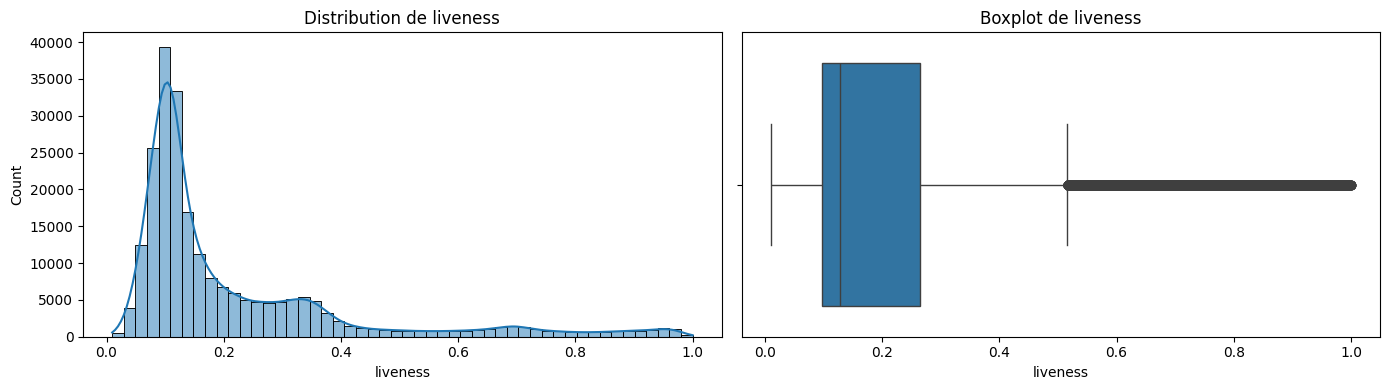

Valeur utilisée (médiane) : 0.1290
Valeurs manquantes restantes : 0


In [12]:
# 1. Statistiques descriptives
print("Statistiques descriptives de liveness :\n")
print(df_music['liveness'].describe())
print(f"\nValeurs manquantes : {df_music['liveness'].isna().sum()}")
print(f"Moyenne : {df_music['liveness'].mean():.4f}")
print(f"Médiane : {df_music['liveness'].median():.4f}")

# 2. Graphiques : distribution histogramme + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_music['liveness'].dropna(), bins=50, ax=axes[0], kde=True)
axes[0].set_title("Distribution de liveness")
sns.boxplot(x=df_music['liveness'].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de liveness")
plt.tight_layout()
plt.show() 

# 3. Flag des valeurs manquantes
df_music['flag_missing_value'] = df_music['liveness'].isna().astype(int)

# 4. Remplacement : la distribution est asymétrique (skewed) à droite,
# la médiane est donc plus représentative que la moyenne (moins sensible
# aux valeurs extrêmes).
mediane = df_music['liveness'].median()
df_music['liveness'] = df_music['liveness'].fillna(mediane)

# Affichage de la valuer utilisé (médiane) - Vérification des valeurs nulles
print(f"Valeur utilisée (médiane) : {mediane:.4f}")
print(f"Valeurs manquantes restantes : {df_music['liveness'].isna().sum()}")

# **Dataviz (approximately 1h)**

## 2.1 Corrélations

Affichez une **heatmap de corrélation**.

L'échelle des couleurs doit être **centrée sur la valeur 0**, afin de distinguer les valeurs négatives et positives. Choisissez une belle **palette divergente**.

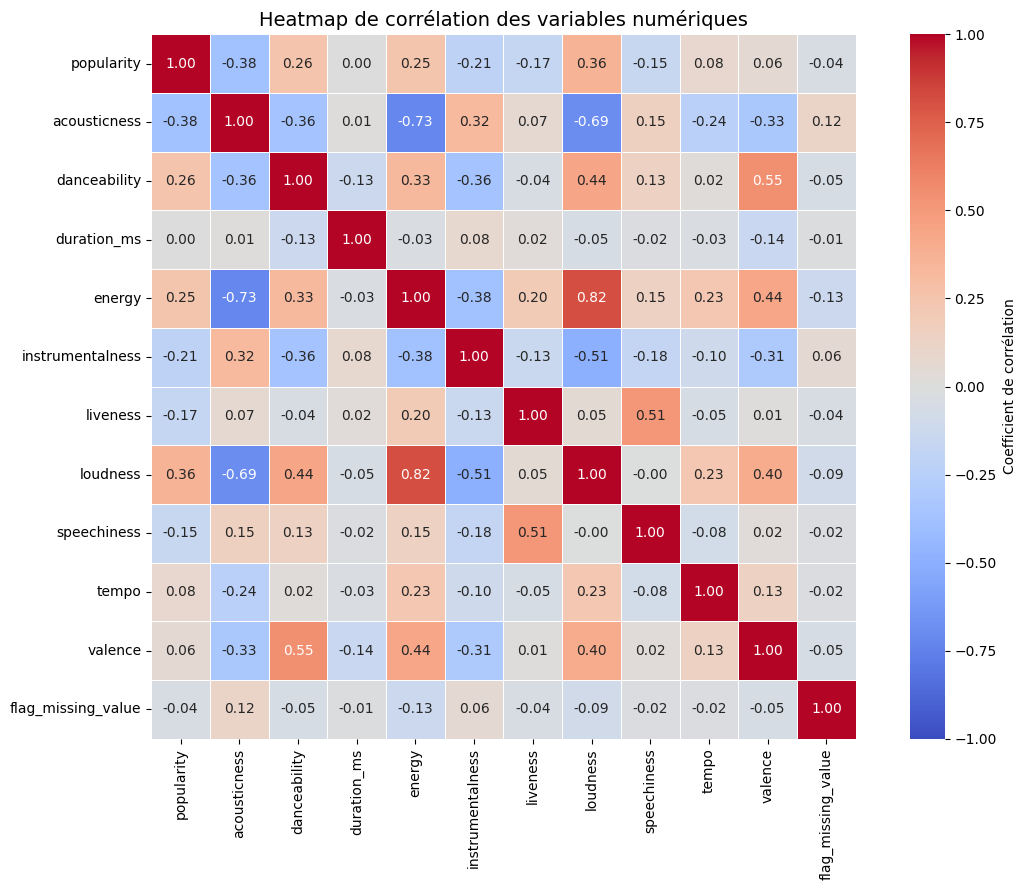

In [13]:
# Your code here :
# dataset dans une variable pour plus de lisibilité
corr = df_music.select_dtypes(include='number').corr()
# graphique heatmap de corrélation
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={'label': 'Coefficient de corrélation'})
plt.title("Heatmap de corrélation des variables numériques", fontsize=14)
plt.tight_layout()

Certaines colonnes semblent avoir de fortes corrélations négatives entre elles.
- Lesquelles ?
- Qu'est-ce que cela signifie ?

In [ ]:
# Your answers here :
# - Les corrélations négatives les plus fortes sont entre :
#     energy et acousticness  (-0.73)
#     loudness et acousticness (-0.69)

# - Cela signifie que :
#   Une chanson énergique (rock, electro, rap, etc..) a tendance à être 
#   moins acoustique (peu d'instruments acoustiques, beaucoup d'utilisation 
#   d'instrument électrique).
#   À l'inverse, une chanson utilisant des instruments acoustique est
#   généralement moins énergique et moins forte.
#   Il y a un rapport entre energie et la puissance du son et le fait
#   d'utiliser des instruments électrique ou accoustique.

Trouvez le coefficient de corrélation entre Energy et Acousticness

In [14]:
# Your code here :
# Calcul du coefficient de corrélation
coef = df_music['energy'].corr(df_music['acousticness'])
print(f"Coefficient de corrélation entre energy et acousticness : {coef:.4f}")

Coefficient de corrélation entre energy et acousticness : -0.7256


## 2.2 Nuage de points
Dessinez un nuage de points (scatterplot) représentant Energy et Acousticness :
- En incluant **uniquement les genres Opera et Reggaeton**
- Chaque genre aura sa propre couleur

Voici un exemple du résultat attendu :

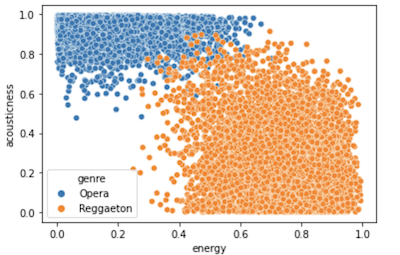

<Axes: xlabel='energy', ylabel='acousticness'>

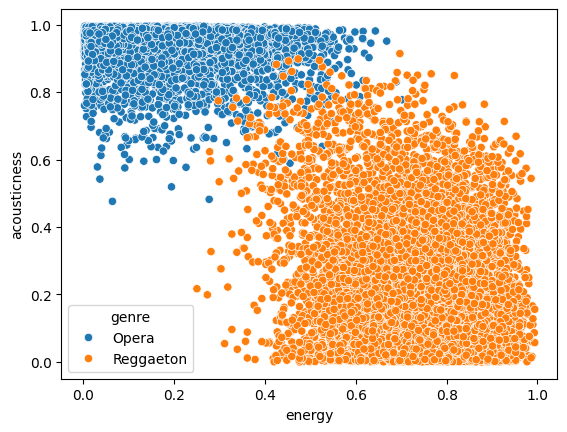

In [15]:
# création d'un filtre avec un masque booléen pour n'avoir que les genre cible `Opera` et `Reggaeton`
filtre = df_music['genre'].isin(['Opera', 'Reggaeton'])
# DataFrame avec le filtre
data_opreg = df_music[filtre]
# création du graphique
sns.scatterplot(data=data_opreg, x='energy', y='acousticness', hue='genre')

## 2.3 Boîte à moustaches
Dessinez sur la même figure 2 boîtes à moustaches : 1 par genre.
- Les boîtes à moustaches doivent être verticales
- Filtrez uniquement sur les genres Opera et Reggaeton
- Vos boîtes à moustaches représentent la danceability

Votre graphique doit être similaire à celui-ci (sans la flèche rouge)

![boxplot](https://raw.githubusercontent.com/murpi/wilddata/master/checkpoint2_boxplot.png)

<Axes: xlabel='genre', ylabel='danceability'>

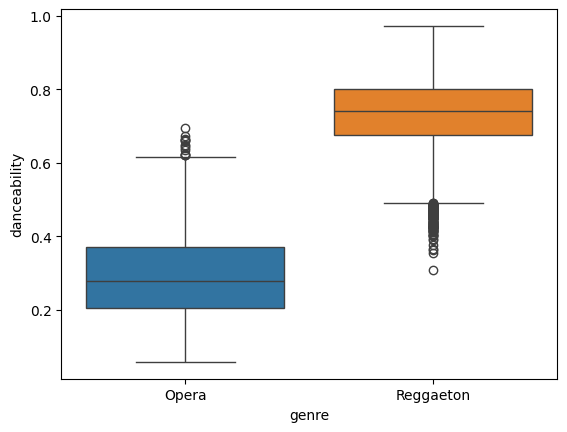

In [16]:
# création d'un filtre avec un masque booléen pour n'avoir que les genre cible `Opera` et `Reggaeton`
filtre = df_music['genre'].isin(['Opera', 'Reggaeton'])
# DataFrame avec le filtre
data_box = df_music[filtre]
# création du graphique
sns.boxplot(data=data_box, x='genre', y='danceability', hue='genre')

Comment le lire ?

Que représente la ligne horizontale près de la flèche rouge ? Qu'est-ce que cela signifie ?

In [ ]:
# Your answer here :
# Le score de `danceability` semble être noté de 0 à 1 avec un min/max de 0.554364/0.989
# La ligne horizontale près de la flèche rouge correspond au 3eme Quartile.
# Cela signifie que 25% des musiques du genre Reggaeton sont superieur à ~ 0.8

# De manière générale le graphique montre que :
# Le genre Opéra est globalement peu dançant avec une boite entre ~ 0.2/0.39
# Le Q3 montre 25% des musiques Opéra entre ~ 04/0.6 avec des outliers allant jusque ~ 0.7
# La mediane se situe à ~ 0.3
#
# Le genre Reggaeton est plutôt de tendance inverse avec une boite entre ~ 0.7/0.8
# ~ 75% des musiques du genre sont au delà de ~ 0.7 (de Q1 à max)
# Néanmoins à l'inverse du genre Opéra on trouve des outliers tirant la moyenne vers le bas
# pour la Serie `danceability`

## 2.4 Graphique interactif
Avec plotly express, dessinez un **histogramme interactif sur energy**.
- Vous ajouterez une animation basée sur le `genre`.
- Assurez-vous que l'échelle verticale soit appropriée. Les histogrammes ne doivent pas "déborder" verticalement, quel que soit le `genre`.

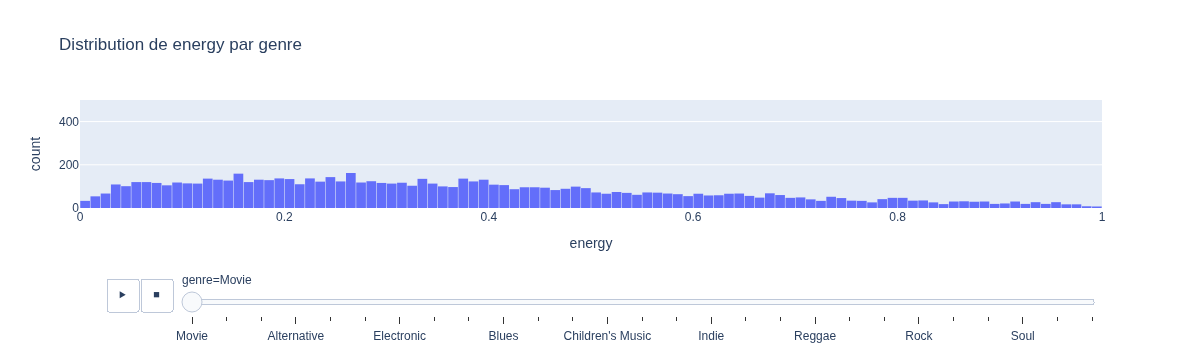

In [17]:
# graphique animé en histogramme
fig = px.histogram(df_music, x='energy', animation_frame='genre', nbins=100, range_x=[0, 1], range_y=[0, 500], title="Distribution de energy par genre")
fig.update_layout(bargap=0.05)

# Machine Learning : Classification (approx 45 min)

## 3.1 Opera & Reggaeton

Tout d'abord, **filtrez votre DataFrame uniquement sur les genres "Opera" et "Reggaeton"**. Vous devriez obtenir un DataFrame avec 17207 lignes.

In [18]:
# Your code here:
# Filtre sur les genres Opéra et Reggaeton
df_or = df_music[df_music['genre'].isin(['Opera', 'Reggaeton'])].copy()
# Affichage du nombr de lignes
print(f"Nombre de lignes : {len(df_or)}")
# Affichage du dataset
df_or.head()

Nombre de lignes : 17207


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,most_popular,flag_missing_value
57582,Opera,Charles Gounod,Ave Maria,2kyEgPaAW8wdpvevPnkf0Z,62,0.993,0.1320,163267,0.0195,0.88800,C,0.0569,-29.760,Major,0.0445,81.616,3/4,0.1400,Other song,0
57583,Opera,Richard Wagner,Tannhäuser: Overture,1U1i1HBJ5H8DY5J4fO8ySg,58,0.831,0.0843,853827,0.1820,0.92600,E,0.1970,-15.880,Major,0.0356,73.750,4/4,0.0604,Other song,0
57584,Opera,Giacomo Puccini,"""Nessun dorma!""",74WjYdm3Lvbwnds4thYPUU,63,0.961,0.1710,180933,0.3080,0.00546,D,0.3190,-12.383,Major,0.0456,171.798,5/4,0.0889,Other song,0
57585,Opera,Gioachino Rossini,Semiramide: Overture (Live),2wG5UNal67Vkyjsdm3Ahat,2,0.896,0.2590,746600,0.1980,0.67900,A,0.6890,-19.621,Major,0.0658,158.284,4/4,0.1590,Other song,0
57586,Opera,Gioachino Rossini,Overture (Sinfonia),1chTrqszWQEOP4RsNuOZf7,52,0.911,0.3390,425000,0.1400,0.67800,E,0.1570,-20.598,Major,0.0470,95.975,4/4,0.2960,Other song,0


Divisez votre jeu de données en un jeu d'entraînement et un jeu de test.

Ensuite, entraînez un modèle de classification qui prédit le genre entre Opera et Reggaeton d'un morceau avec les features de votre choix.

Vous pouvez choisir votre algorithme.

Essayez d'obtenir le meilleur score de précision sur votre jeu de test !!! (sans overfitting)

In [19]:
df_or.select_dtypes('number').columns.to_list()

['popularity',
 'acousticness',
 'danceability',
 'duration_ms',
 'energy',
 'instrumentalness',
 'liveness',
 'loudness',
 'speechiness',
 'tempo',
 'valence',
 'flag_missing_value']

In [32]:
# Your code here:
# On défini la liste de features dans une variable
features = ['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'loudness', 'speechiness', 'tempo', 'valence']

# Création de nos jeu de données pour les features (X) et la target (y)
X = df_or[features]
y = df_or['genre']

# Division du jeu de données en entrainement et test en 80/20 (train/test) - random_state pour la reproductibilité
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

# Entrainement du modèle
model = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
model.fit(X_train, y_train)

# Vérification des métriques
train_score = model.score(X_train, y_train)
test_score  = model.score(X_test, y_test)
print(f"Score train : {train_score:.4f}")
print(f"Score test  : {test_score:.4f}\n")
print(classification_report(y_test, model.predict(X_test)))

Score train : 1.0000
Score test  : 0.9994

              precision    recall  f1-score   support

       Opera       1.00      1.00      1.00      1656
   Reggaeton       1.00      1.00      1.00      1786

    accuracy                           1.00      3442
   macro avg       1.00      1.00      1.00      3442
weighted avg       1.00      1.00      1.00      3442



Affichez également une matrice de confusion. Combien de chansons d'Opera sont mal prédites sur votre jeu de test ?

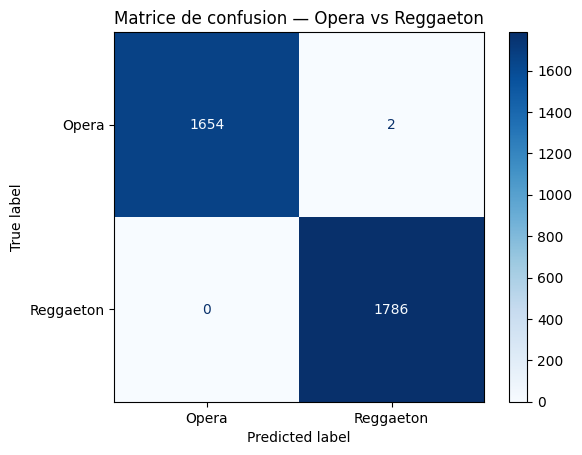

In [35]:
# Your code here:
# prediction sur la target `genre`
y_pred = model.predict(X_test)
# Comparaison entre données réelles et données prédites dans le même ordre
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
# Affichage de la matrice de confusion
#        True Positives - False Positives  
#        False Negatives - True Negatives      
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice de confusion — Opera vs Reggaeton")
plt.show()

## 3.2 Rap & Hip-Hop

Maintenant, entraînez un autre modèle (vous pouvez garder le même algorithme et les mêmes paramètres) sur ces 2 genres : Rap et Hip-Hop.
Vous devriez avoir un score plus faible que précédemment, pourquoi ?

In [22]:
# Your code here:
df_rh = df_music[df_music['genre'].isin(['Rap', 'Hip-Hop'])].copy()
print(f"Nombre de lignes : {len(df_rh)}")

# On défini la liste de features dans une variable
features = ['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'loudness', 'speechiness', 'tempo', 'valence']

# Création des jeu de données pour les features (X) et la target (y)
X = df_rh[features]
y = df_rh['genre']

# # Division du jeu de données en entrainement et test en 80/20 (train/test) - random_state pour la reproductibilité
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

# Entrainement du modèle
model_rh = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
model_rh.fit(X_train, y_train)

# Vérification des métriques
print(f"Score train : {model_rh.score(X_train, y_train):.4f}")
print(f"Score test  : {model_rh.score(X_test, y_test):.4f}")
print()
print(classification_report(y_test, model_rh.predict(X_test)))

# Le score est beaucoup plus faible qu'avec Opéra vs Reggaeton
# Cela est dut au fait que le Rap et le Hip-Hop sont très proches musicalment
# Le modèle a donc beaucoup plus de mal à les distinguer que Opera et Reggaeton,
# qui sont à l'opposé sur presque toutes les series.

Nombre de lignes : 18527
Score train : 0.7367
Score test  : 0.2779

              precision    recall  f1-score   support

     Hip-Hop       0.29      0.31      0.30      1859
         Rap       0.26      0.25      0.26      1847

    accuracy                           0.28      3706
   macro avg       0.28      0.28      0.28      3706
weighted avg       0.28      0.28      0.28      3706



# Machine Learning : Régression (approx 45 min)
Dans cette partie nous allons essayer de prédire le **"loudness"** d'un morceau.

## Régression univariée : Dans un premier temps, nous allons entraîner un modèle de **régression linéaire univariée**.


Trouvez la colonne la plus corrélée avec **loudness**.

In [38]:
# Your code here :
# recherche des valeurs les plus corrélées
corr_loudness = (df_music.select_dtypes(include='number').corr()['loudness'].drop('loudness').sort_values(ascending=False))
print("Corrélations avec loudness :")
print(corr_loudness)

Corrélations avec loudness :
energy                0.816088
danceability          0.438668
valence               0.399901
popularity            0.363011
tempo                 0.228364
liveness              0.047947
speechiness          -0.002273
duration_ms          -0.047618
flag_missing_value   -0.089573
instrumentalness     -0.506320
acousticness         -0.690202
Name: loudness, dtype: float64


Divisez votre jeu de données en un jeu d'entraînement et un jeu de test (en utilisant 80% pour l'entraînement et 20% pour le test).

Utilisez un `random_state` de **1** (pour des raisons de reproductibilité).

In [39]:
# Your code here :
# Définition de la feature (X) ainsi que de la target (y)
X = df_music[['energy']]
y = df_music['loudness']
# Division du jeu de données en jeu d'entrainement et jeu de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
# Vérification des dimensions
print(f"Train : {X_train.shape}, Test : {X_test.shape}")

Train : (186180, 1), Test : (46545, 1)


Maintenant entraînez votre modèle sur le jeu d'entraînement.

In [40]:
# Your code here :
# Entrainement du modèle
reg = LinearRegression()
reg.fit(X_train, y_train)
# Affichage des métriques
print(f"Coefficient : {reg.coef_[0]:.6f}")
print(f"Intercept   : {reg.intercept_:.6f}")

Coefficient : 18.567752
Intercept   : -20.171581


Et évaluez-le sur le jeu de test. Si vous avez tout fait correctement, votre score devrait être `0.6689508695872618`.

In [41]:
# Your code here :
# test score
score_test = reg.score(X_test, y_test)
# Vérification du score avec condition sur l'affichage
if score_test != 0.6689508695872618:
    print("✅ Score conforme à la valeur attendue.")
    print(f"Score R² sur le jeu de test : {score_test}")
else:
    print("❎ Score pas conforme à la valeur attendue.")

✅ Score conforme à la valeur attendue.
Score R² sur le jeu de test : 0.6689508695872617


BONUS : Visualisez vos données avec un nuage de points (différentes couleurs pour le jeu d'entraînement et le jeu de test).

Ajoutez une ligne de régression.

Vous devriez obtenir quelque chose comme ceci. Mais bien sûr, votre graphique aura de plus belles couleurs, et un titre !

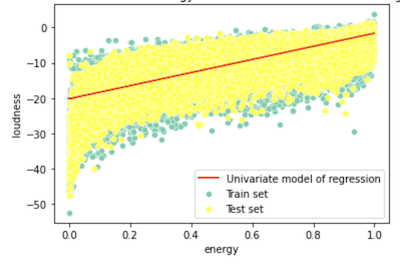

/home/oneup/Work/machine-learning/env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


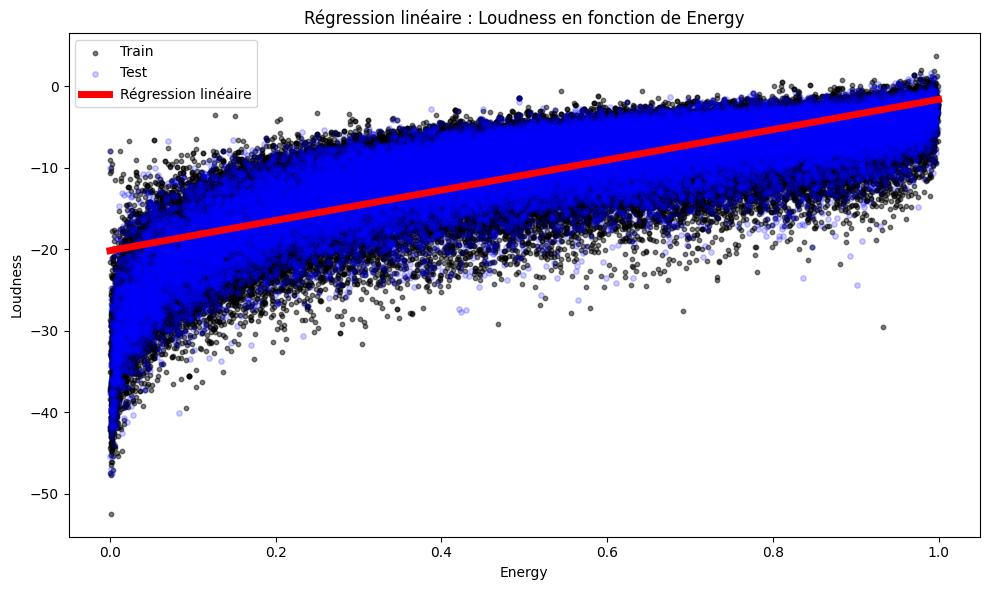

In [44]:
# BONUS : scatter avec couleurs distinctes train/test + droite de régression
# Nuage de points entre les jeu de données d'entrainement et de test
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.5, s=10, color='black', label='Train')
plt.scatter(X_test,  y_test,  alpha=0.2, s=15, color='blue', label='Test')
# Droite de régression 
x_line = np.linspace(0, 1, 100).reshape(-1, 1)
y_line = reg.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=5, label='Régression linéaire')
# informations sur le graphique
plt.xlabel("Energy")
plt.ylabel("Loudness")
plt.title("Régression linéaire : Loudness en fonction de Energy")
plt.legend()
plt.tight_layout()

Affichez l'équation de la régression.

In [28]:
# Remplace a par le coefficient et b par l'intercept du modèle
# Remplacement du coef et de l'intercept par a et b
a = reg.coef_[0]
b = reg.intercept_
# Affichege de l'équation f(x) = ax + b
print(f"Équation de la régression :")
print(f"  loudness = {a:.4f} * energy + ({b:.4f})")

Équation de la régression :
  loudness = 18.5678 * energy + (-20.1716)


Prédisez la valeur de "**loudness**" pour une valeur d'energy de 0.62

In [47]:
# Your code here :
# prediction pour une valeur energy = 0.62
valeur_energy = 0.62
pred = reg.predict(pd.DataFrame({'energy': [valeur_energy]}))[0]
print(f"Loudness prédit pour energy = {valeur_energy} : {pred:.4f}")

Loudness prédit pour energy = 0.62 : -8.6596


## Régression multivariée

Maintenant vous allez prédire le **loudness** d'un morceau avec toutes les autres colonnes numériques.

Vous effectuerez toutes les étapes nécessaires et garderez un `random_state` de 1.

Votre score de test devrait être meilleur (entre 0.75 et 0.8).

Y a-t-il du sur-apprentissage ?

In [49]:
# Your code here :
# On défini la liste de features
features = ['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'speechiness', 'tempo', 'valence']

# Création de nos jeu de données pour les features (X) et la target (y)
X = df_music[features]
y = df_music['loudness']

# Division du jeu de données en entrainement et test en 80/20 (train/test) - random_state pour la reproductibilité
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Entraînement du modèle de régression linéaire
reg_multi = LinearRegression()
reg_multi.fit(X_train, y_train)

# Vérification des métriques
train_score = reg_multi.score(X_train, y_train)
test_score  = reg_multi.score(X_test, y_test)
print(f"Score R² train : {train_score:.4f}")
print(f"Score R² test  : {test_score:.4f}")
print(f"Écart train-test : {train_score - test_score:.4f}")

# Pas de suapprentissage notable
# Les scores train et test sont très proches, donc
# l'écart minime confirme que le modèle généralise bien.

Score R² train : 0.7606
Score R² test  : 0.7598
Écart train-test : 0.0008


# Bonus - Comparaison entre le top 1% de popularité et le jeu de données complet (question bonus)
Trouvez un moyen de comparer les chansons avec la plus haute popularité et les autres. Quelque chose comme cet exemple, mais vous pouvez être créatif.

Ici nous avons comparé les fréquences par genre (35% des chansons les plus populaires sont "pop", contre 4% de chansons pop dans le jeu de données total)


![comparison](https://raw.githubusercontent.com/murpi/wilddata/master/checkpoint2_comparison.png)

In [ ]:
len